In [16]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [17]:
wine = datasets.load_wine()
X = wine.data
y = wine.target
print("Shape of Features: ", X.shape)
print("Shape of Labels: ", y.shape)

Shape of Features:  (178, 13)
Shape of Labels:  (178,)


In [18]:
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [19]:
print(wine.target_names)

['class_0' 'class_1' 'class_2']


In [25]:
df = pd.DataFrame(X, columns=wine.feature_names)
df["Target"] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

In [26]:
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64


In [52]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.1, random_state=42)

In [53]:
mlp1 = MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000, learning_rate_init=0.001, random_state=42)
mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, learning_rate_init=0.001, random_state=42)

In [54]:
def calculate_and_plot_metrics(X_train, y_train, X_test, y_test, title):
    mlp1.fit(X_train, y_train)
    y_pred_mlp1 = mlp1.predict(X_test)

    mlp2.fit(X_train, y_train)
    y_pred_mlp2 = mlp2.predict(X_test)

    # Calculate metrics
    def calculate_metrics(y_true, y_pred):
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=1)
        recall = recall_score(y_true, y_pred, average='weighted')
        return accuracy, f1, precision, recall
 # Metrics for MLP1
    accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1 = calculate_metrics(y_test, y_pred_mlp1)

    # Metrics for MLP2
    accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2 = calculate_metrics(y_test, y_pred_mlp2)
# Confusion Matrix and Visualization (MLP1)
    cm_mlp1 = confusion_matrix(y_test, y_pred_mlp1)
    disp_mlp1 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp1, display_labels=wine.target_names)
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    disp_mlp1.plot(cmap='viridis', values_format='d', ax=axes[0, 0])
    axes[0, 0].set_title("MLP1 Confusion Matrix")

    # Loss Curve (MLP1)
    axes[0, 1].plot(mlp1.loss_curve_)
    axes[0, 1].set_title("MLP1 Loss Curve")
    axes[0, 1].set_xlabel('Iterations')
    axes[0, 1].set_ylabel('Cost')

    # Confusion Matrix and Visualization (MLP2)
    cm_mlp2 = confusion_matrix(y_test, y_pred_mlp2)
    disp_mlp2 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp2, display_labels=wine.target_names)
    disp_mlp2.plot(cmap='viridis', values_format='d', ax=axes[1, 0])
    axes[1, 0].set_title("MLP2 Confusion Matrix")

    # Loss Curve (MLP2)
    axes[1, 1].plot(mlp2.loss_curve_)
    axes[1, 1].set_title("MLP2 Loss Curve")
    axes[1, 1].set_xlabel('Iterations')
    axes[1, 1].set_ylabel('Cost')

# Calculate 10-fold cross-validation results
    cross_val_scores1_mlp1 = cross_val_score(mlp1, X_train, y_train, cv=10, scoring='f1_weighted')
    cross_val_scores1_mlp2 = cross_val_score(mlp2, X_train, y_train, cv=10, scoring='f1_weighted')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1, accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2

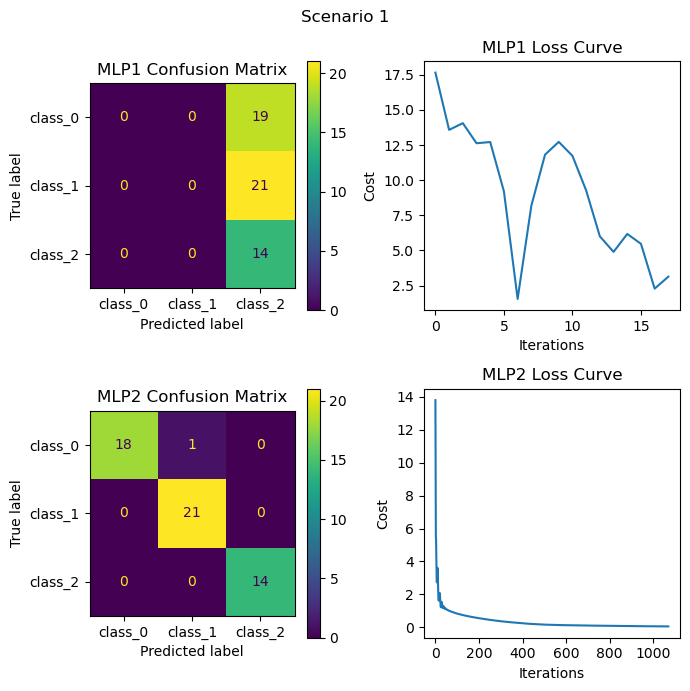

Scenario 1 (MLP1):
Accuracy: 0.2593
F1 Score: 0.1068
Precision: 0.8080
Recall: 0.2593

Scenario 1 (MLP2):
Accuracy: 0.9815
F1 Score: 0.9814
Precision: 0.9823
Recall: 0.9815

Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score: 0.2315341521223874
Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score: 0.9346122396122396


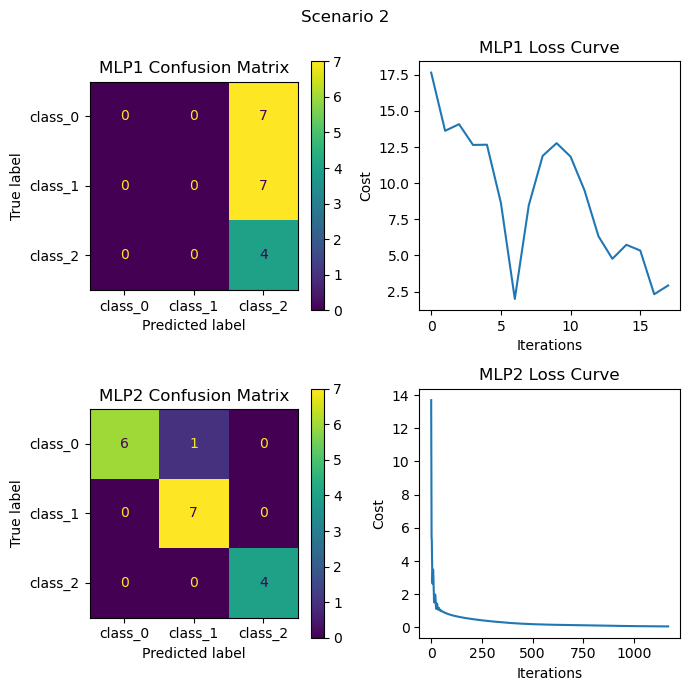

Scenario 2 (MLP1):
Accuracy: 0.2222
F1 Score: 0.0808
Precision: 0.8272
Recall: 0.2222

Scenario 2 (MLP2):
Accuracy: 0.9444
F1 Score: 0.9442
Precision: 0.9514
Recall: 0.9444

Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score: 0.22674655388471177
Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score: 0.9561985236985237
Comparison:
Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy: 0.037037037037037035
Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy: 0.03703703703703709
Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score: 0.025945731828084767
Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score: 0.03728701868236739


In [55]:
# Calculations for Scenario 1
accuracy1_mlp1, f1_1_mlp1, precision1_mlp1, recall1_mlp1, accuracy1_mlp2, f1_1_mlp2, precision1_mlp2, recall1_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2 = calculate_and_plot_metrics(X_train1, y_train1, X_test1, y_test1, "Scenario 1")

# Outputs for Scenario 1
print("Scenario 1 (MLP1):")
print(f"Accuracy: {accuracy1_mlp1:.4f}\nF1 Score: {f1_1_mlp1:.4f}\nPrecision: {precision1_mlp1:.4f}\nRecall: {recall1_mlp1:.4f}\n")
print("Scenario 1 (MLP2):")
print(f"Accuracy: {accuracy1_mlp2:.4f}\nF1 Score: {f1_1_mlp2:.4f}\nPrecision: {precision1_mlp2:.4f}\nRecall: {recall1_mlp2:.4f}\n")
print("Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores1_mlp1))
print("Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores1_mlp2))

# Calculations for Scenario 2
accuracy2_mlp1, f1_2_mlp1, precision2_mlp1, recall2_mlp1, accuracy2_mlp2, f1_2_mlp2, precision2_mlp2, recall2_mlp2, cross_val_scores2_mlp1, cross_val_scores2_mlp2 = calculate_and_plot_metrics(X_train2, y_train2, X_test2, y_test2, "Scenario 2")

# Outputs for Scenario 2
print("Scenario 2 (MLP1):")
print(f"Accuracy: {accuracy2_mlp1:.4f}\nF1 Score: {f1_2_mlp1:.4f}\nPrecision: {precision2_mlp1:.4f}\nRecall: {recall2_mlp1:.4f}\n")
print("Scenario 2 (MLP2):")
print(f"Accuracy: {accuracy2_mlp2:.4f}\nF1 Score: {f1_2_mlp2:.4f}\nPrecision: {precision2_mlp2:.4f}\nRecall: {recall2_mlp2:.4f}\n")
print("Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores2_mlp1))
print("Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores2_mlp2))

# Scenario 1 and Scenario 2 comparison
print("Comparison:")
print("Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy:", accuracy1_mlp1 - accuracy2_mlp1)
print("Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy:", accuracy1_mlp2 - accuracy2_mlp2)
print("Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score:", f1_1_mlp1 - f1_2_mlp1)
print("Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score:", f1_1_mlp2 - f1_2_mlp2)